# Bone_Fracture_Binary_Classification_CNN

# 1. Business Understanding

Medical facilities face high X-ray volumes, leading to diagnostic fatigue and potential delays. An automated tool can assist radiologists by pre-screening images for fractures across multiple body regions.

**Business Objectives**
Build a Deep Learning model to accurately distinguish between `Fractured` and `Non-fractured` X-rays. & Reduce the time taken to identify fractures in emergency settings. 

**Generalization:** Ensure the model works across various anatomical regions (limbs, hips, spine, etc.)

**Success Criteria**
* **Technical:** Achieve high sensitivity (recall) and an accuracy threshold. 
* **Practical:** Good generalization across different regions


# 2. Data Understanding

**Dataset Overview**
The [Bone Fracture Multi-Region X-ray Data](https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data) is a curated collection of **10,580 images** from three major sources (Mohan Kumar, Abdelaziz Faramawy, and Harsha Arya).

**Key Statistics**
* **Total Images:** 10,580
* **Split:** 9,246 Train | 828 Val | 506 Test.
* **Classes:** Binary (`Fractured` vs. `Non-fractured`).
* **Scope:** Multi-region (hands, legs, hips, knees, lumbar, etc.).

**Data Quality**
* **Diversity:** High anatomical variety ensures the model isn't biased toward just one bone type.



## 2.1 Importing Libraries

Key libraries used:
- NumPy and Pandas for data manipulation
- Matplotlib and Seaborn for visualization
- TensorFlow/Keras for building and training deep learning models
- OpenCV for image processing tasks


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from skimage.feature import hog
from skimage import exposure
import warnings 
warnings.filterwarnings("ignore")


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2, ResNet152V2, VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True # ignore partially broken images.

from sklearn.metrics import classification_report, confusion_matrix, f1_score

2026-03-23 15:04:47.520537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774278287.700470      95 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774278287.746107      95 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774278288.213946      95 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774278288.213988      95 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774278288.213990      95 computation_placer.cc:177] computation placer alr

## 2.2 Loading Dataset

- The dataset is loaded from the Kaggle directory, which contains X-ray images categorized into different classes. 
- These images are used to train, validate, and test the deep learning models.

In [2]:
dataset_path = "/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
print(os.listdir(dataset_path))

['val', 'test', 'train']


## 2.3 Loading Data Folders
- The dataset is organized into separate folders for training, validation, and testing. 
- Each folder contains subfolders representing different classes (fractured and not fractured).

In [3]:
train_dir = "/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train"
test_dir = "/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test"
val_dir = "/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val"

## 2.4 Loading Data Generator

Data generators are used to efficiently load and preprocess images in batches instead of loading the entire dataset into memory. 

> `ImageDataGenerator` from TensorFlow is used to handle image rescaling and preprocessing. 
It prepares the images before feeding them into the model, ensuring consistency in input format.


In [4]:
# Train
train_datagen = ImageDataGenerator(
    rescale =  1./225, # squashes pixel value in 0 to 1 range
    rotation_range = 10,
    zoom_range = 0.2,
    horizontal_flip = True
    
)

# Validation
val_datagen = ImageDataGenerator(rescale = 1./255)

# Test
test_datagen = ImageDataGenerator(rescale = 1./255)


## 2.5. Creating Data Generator

- Data generators are created using the `flow_from_directory` method, which reads images directly from the dataset folders.

> `flow_from_directory` automatically assigns labels based on folder names and generates batches of images and labels during training.


In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode= "binary",
    shuffle = True
    
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode= "binary",
    shuffle = False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224,224),
    batch_size = 32,
    class_mode= "binary",
    shuffle = False
)

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.


## 2.6. Checking Class Labels

The generator assigned numerical labels to each class based on folder names. 

- fractured → 0
- not fractured → 1

In [6]:
print("The Classes Allocated to Labels are: ")
print(train_generator.class_indices)

The Classes Allocated to Labels are: 
{'fractured': 0, 'not fractured': 1}


# 3. Exploratory Data Analysis (EDA)

In this project, EDA focuses on visualizing X-ray images, analyzing class distribution, and understanding image characteristics such as pixel intensity and variation.


In [7]:
sns.set_theme(style = "whitegrid",
             rc = {"grid.linestyle" : "--"},
             palette = "pastel")
plt.rcParams["figure.figsize"] = (8,5)

## 3.1 Visualizing Sample Images

Sample images from the dataset are visualized to get an initial understanding of the data. 
This helped in identifying differences between fractured and non-fractured X-rays.


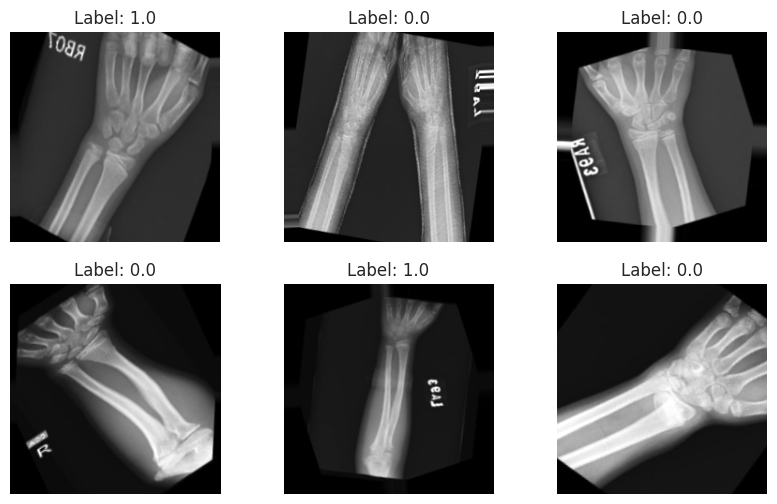

In [8]:
images, labels = next(train_generator)

plt.figure(figsize = (10,6))

for i in range(6):
    plt.subplot(2,3,i+1) # 2 rows, 3 column
    plt.imshow(np.clip(images[i],0,1))
    plt.title("Label: "+ str(labels[i]))  
    plt.axis("off")
  

plt.show()


## 3.2 Fracture and Non Fracture Images

Images from both classes (fractured and non-fractured) are displayed side by side for comparison.

>- Presence of cracks or discontinuities in bones (fractured)

>- Smooth and continuous bone structure (non-fractured)

In [9]:
def sample_images(generator):
    images, labels = next(generator)

    fracture_img = None
    normal_img = None

    for i in range(len(labels)):
        if labels[i] == 0 and fracture_img is None: # fracture = 0
            fracture_img = images[i]

        elif labels[i] == 1 and normal_img is None: # Not Fracture Img
            normal_img = images[i]

        if fracture_img is not None and normal_img is not None:
            break

    return fracture_img, normal_img

### 3.2.1 *Visualizing Sample Images*

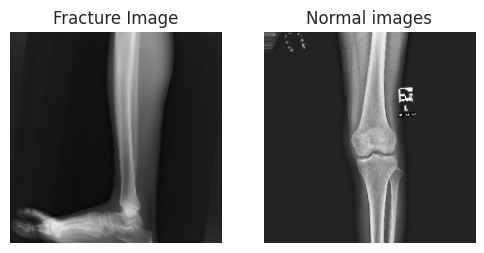

In [10]:
fracture_img, normal_img = sample_images(train_generator)

plt.figure(figsize = (6,3))

plt.subplot(1,2,1)
plt.imshow(np.clip(fracture_img,0,1))
plt.title("Fracture Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(np.clip(normal_img,0,1))

plt.title("Normal images")
plt.axis("off")
        
plt.show()

## 3.3 Class Distribution
- Shows how many images belong to each class

not fractured: 4640 images
fractured: 4606 images


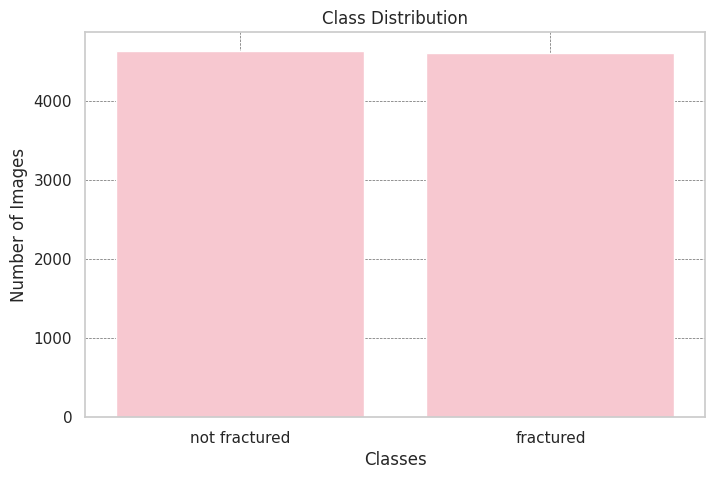

In [11]:
classes = os.listdir(train_dir)

counts = []

for i in classes:
    path = os.path.join(train_dir, i)

    counts.append(len(os.listdir(path)))
    print(f"{i}: {len(os.listdir(path))} images")

# Ploting 
plt.figure()
sns.barplot(x=classes, y=counts, color = "pink")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.6)



plt.show()

## 3.4 Image Statistics (Mean, Median, Std)

- Mean: Represents the average brightness of the images
- Median: Indicates the central pixel intensity value
- Standard Deviation: Shows the variation in pixel intensity

In [12]:
image_paths = []

for cls in classes:
    folder = os.path.join(train_dir, cls)
    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))

means = []
medians = []
stds = []

for path in image_paths[:100]:
    img = cv2.imread(path)
    img = cv2.resize(img, (224, 224))

    means.append(np.mean(img))
    medians.append(np.median(img))
    stds.append(np.std(img))

print("Mean: ", np.mean(means))
print("Median: ", np.mean(medians))
print("Std: ", np.mean(stds))

Premature end of JPEG file
Premature end of JPEG file


Mean:  58.48795539700255
Median:  34.85
Std:  51.04363325668084


The relatively high standard deviation indicates significant variation in pixel intensities, suggesting that the dataset contains diverse image patterns. 

The difference between mean and median interpret that the images may have uneven brightness distribution, which is common in medical X-ray data.


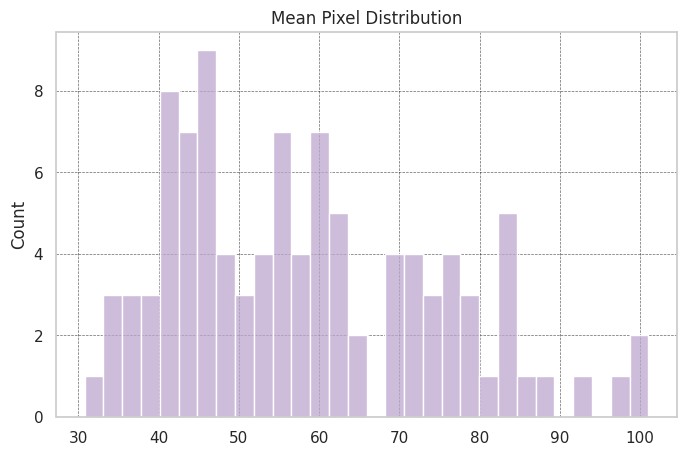

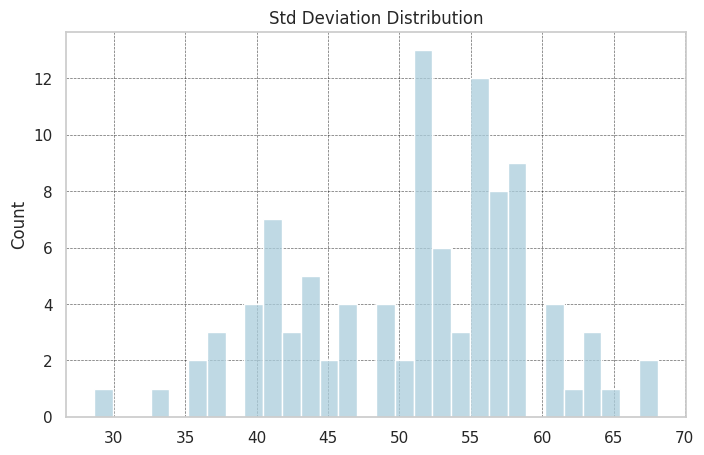

In [13]:
sns.histplot(means, bins=30, color = "#BDA6CE")
plt.title("Mean Pixel Distribution")
plt.grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.6)
plt.show()

sns.histplot(stds, bins=30, color = "#AACDDC")
plt.title("Std Deviation Distribution")
plt.grid(True, color='black', linestyle='--', linewidth=0.5, alpha=0.6)
plt.show()

## 3.5 Pixel Intensity Distribution
- Shaow how pixel values (0-255) are distributed
- Helps detect contrast & brightness patterns

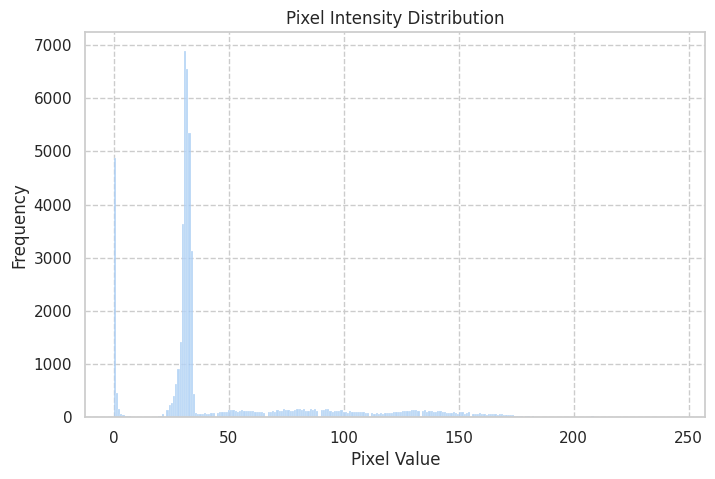

In [14]:
img = cv2.imread(image_paths[1], cv2.IMREAD_GRAYSCALE)

sns.histplot(img.ravel(), bins = 256)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()



# 4. Image Processing & Feature Analysis

## 4.1 Sobel Edge Detection

- Sobel works by detecting change in pixel intensity.
-  If change is:

> Small → smooth area

> Large → edge
> 
- Sobel operator detects edges by measuring changes in pixel intensity,
which helps highlight bone boundaries and fracture lines in X-ray images.

- Sobel shows what early CNN layers are detecting

- Conv Layer 1 → detects edges

In [15]:
def apply_sobel(image):

    # Converting from 0-1 -> 0-255
    img = (image * 255).astype(np.uint8)

    # Converting to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Sobel Operator
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1)

    # Converting For Display
    sobelx = cv2.convertScaleAbs(sobelx)
    sobely = cv2.convertScaleAbs(sobely)

    return gray, sobelx, sobely

    

### 4.1.1 *Visualizing Sobel Images*


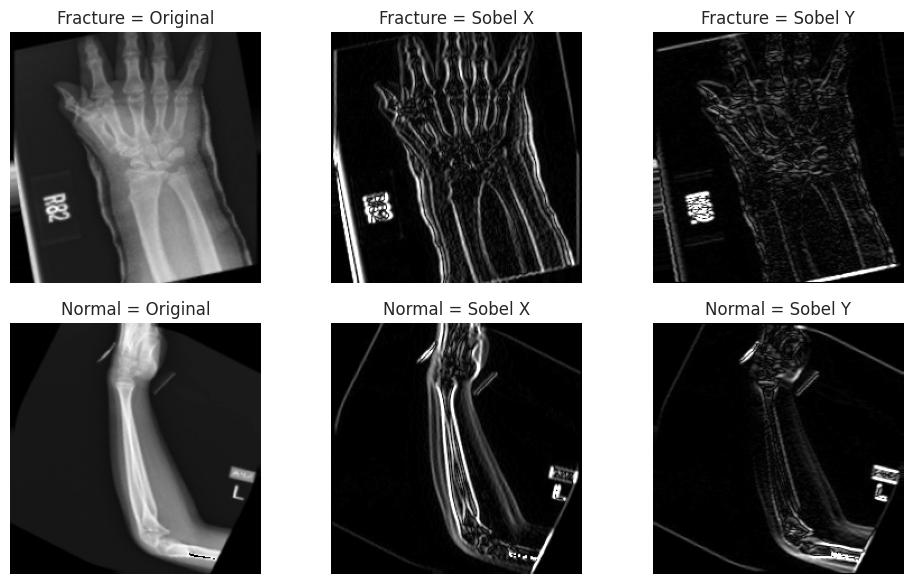


Fractures are not just 'visible cracks' They are 'disruptions in edge continuity'
while normal images exhibit smooth and continuous edges.  


In [16]:
fracture_img, normal_img = sample_images(train_generator)

# Aplying Sobel
f_gray, f_sx, f_sy = apply_sobel(fracture_img)
n_gray, n_sx, n_sy = apply_sobel(normal_img)

plt.figure(figsize = (10,6))

# Fracture Row
plt.subplot(2,3,1)
plt.imshow(f_gray, cmap= "gray")
plt.title("Fracture = Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(f_sx, cmap= "gray")
plt.title("Fracture = Sobel X")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(f_sy, cmap= "gray")
plt.title("Fracture = Sobel Y")
plt.axis("off")

# Not Fracture Row
plt.subplot(2,3,4)
plt.imshow(n_gray, cmap= "gray")
plt.title("Normal = Original")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(n_sx, cmap= "gray")
plt.title("Normal = Sobel X")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(n_sy, cmap= "gray")
plt.title("Normal = Sobel Y")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\nFractures are not just 'visible cracks' They are 'disruptions in edge continuity'\nwhile normal images exhibit smooth and continuous edges.  ")

## 4.2 Canny Egde Detection

- Canny edge detection provides clearer and more refined edges compared to Sobel.
  
- It performs noise reduction and uses double thresholding, while effectively highlights fracture lines as thin discontinuities while suppressing noise, 
making it more suitable for analyzing bone fractures in X-ray images.

In [17]:
# Canny function

def apply_canny(image):

    img = (image * 255).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Guassian Blur removes noise before detecting edges
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Cany Edge Detection
    edges = cv2.Canny(blur, 50, 100)
    # 100 -> Waek edge Threshold
    # 200 - > strong Edge Threshold

    return gray, edges


### 4.2.1 *Visualizing Canny Images*

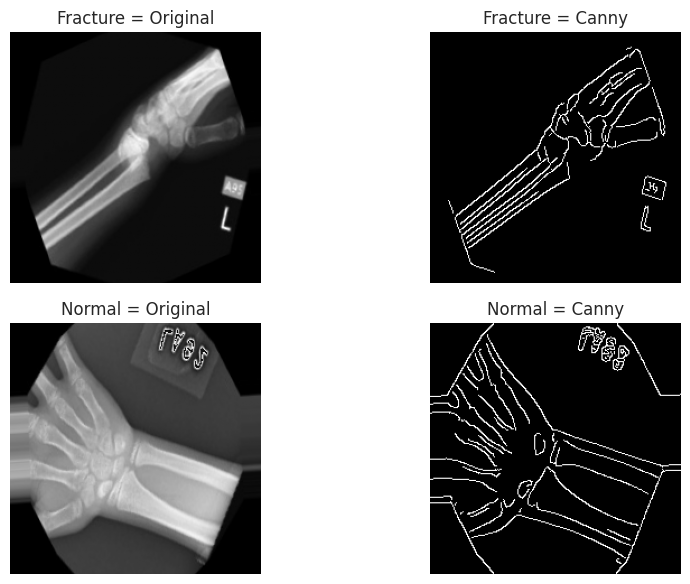



Canny edge detection highlights the structural patterns of bones by extracting clean and thin edges.
Fractured images show slight discontinuities and irregularities in edge alignment,whereas normal images exhibit smooth and continuous edge structures.


In [18]:
fracture_img, normal_img = sample_images(train_generator)

# Applying Canny
f_gray, f_edges = apply_canny(fracture_img)
n_gray, n_edges = apply_canny(normal_img)

plt.figure(figsize = (10,6))

# Fracture Row
plt.subplot(2,2,1)
plt.imshow(f_gray, cmap = "gray")
plt.title("Fracture = Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(f_edges, cmap = "gray")
plt.title("Fracture = Canny")
plt.axis("off")

# Normal Images
plt.subplot(2,2,3)
plt.imshow(n_gray, cmap = "gray")
plt.title("Normal = Original")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(n_edges, cmap = "gray")
plt.title("Normal = Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\n")
print("Canny edge detection highlights the structural patterns of bones by extracting clean and thin edges.\nFractured images show slight discontinuities and irregularities in edge alignment,whereas normal images exhibit smooth and continuous edge structures.")

## 4.3  HOG (Histogram of Oriented Gradients)

- HOG is a feature extraction technique that captures edge directions and structural patterns in images, 
which helps in identifying shape and object characteristics.
- HOG = Direction of edges + strength of edges
- HOG ≈ what CNN internally learns

In [19]:
# Hog Function

def apply_hog(image):

    img = (image * 255).astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # HOG
    fd, hog_img = hog(
        gray,
        orientations = 9, # Divides edge directions into 9 angles
        pixels_per_cell = (8,8), # Image divided into small 8x8 blocks
        cells_per_block = (2,2), # Combines neighboring cells → better pattern detection
        visualize = True        
    )
    # Visibilty Improve
    hog_img = exposure.rescale_intensity(hog_img, in_range = (0,10))

    return gray, hog_img
    

### 4.3.1 Visualizing HOG Images

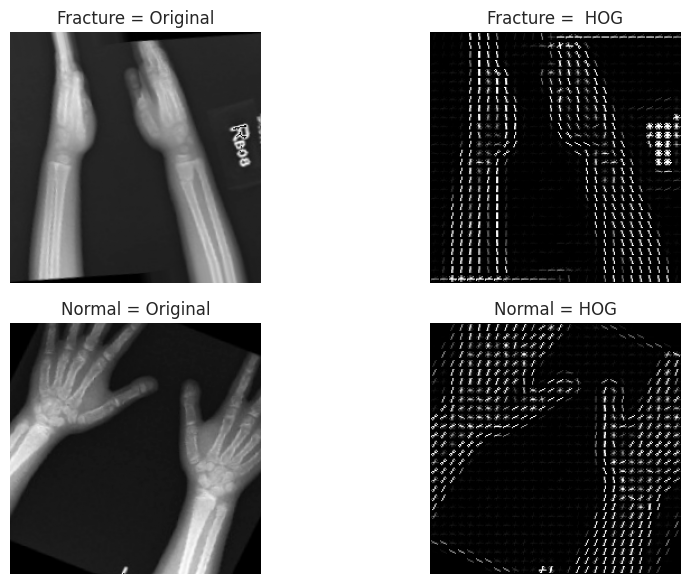


Fracture is not just edge break, It is change in orientation pattern
HOG showed that fractured bones have irregular gradient orientations and disrupted structural patterns,
while normal bones maintain consistent and aligned gradient directions.


In [20]:
fracture_img, normal_img = sample_images(train_generator)

# Apply HOG
f_gray, f_hog = apply_hog(fracture_img)
n_gray, n_hog = apply_hog(normal_img)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Fracture
plt.subplot(2,2,1)
plt.imshow(f_gray, cmap='gray')
plt.title("Fracture = Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(f_hog, cmap='gray')
plt.title("Fracture =  HOG")
plt.axis("off")

# Normal
plt.subplot(2,2,3)
plt.imshow(n_gray, cmap='gray')
plt.title("Normal = Original")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(n_hog, cmap='gray')
plt.title("Normal = HOG")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\nFracture is not just edge break, It is change in orientation pattern")
print("HOG showed that fractured bones have irregular gradient orientations and disrupted structural patterns,\nwhile normal bones maintain consistent and aligned gradient directions.")

# 5. CNN Modeling (Baseline)

- A Convolutional Neural Network (CNN) is built as a baseline model to perform binary classification of X-ray images into fractured and non-fractured categories.

- CNNs automatically learn spatial features such as edges, textures, and patterns, which are important for detecting fractures in medical images.

> This baseline model serves as a reference to compare with more advanced models like transfer learning.

## 5.1 Model Architecture

The CNN architecture consists of multiple layers designed to extract and learn features from images:

- ***Convolutional Layers***: Extract important features such as edges and patterns
- ***Max Pooling Layers***: Reduce spatial dimensions and retain important information
- ***Flatten Layer***: Converts 2D feature maps into a 1D vector
- ***Dense Layers***: Perform classification based on extracted features
- ***Dropout Layer***: Helps prevent overfitting by randomly disabling neurons

This layered structure allows the model to progressively learn complex patterns from X-ray images.

In [21]:
model = Sequential()

# 1. First Convolution Layer
model.add(Conv2D(filters= 32, kernel_size = (3,3), activation = "relu", padding = "valid",  input_shape = (224,224,3)))
model.add(MaxPooling2D(pool_size = (2,2)))

# 2. Second Layer
model.add(Conv2D(64, (3,3), padding = "valid", activation = "relu"))
model.add(MaxPooling2D(pool_size = (2,2)))

# 3. Third Layer
model.add(Conv2D(128, (3,3), activation = "relu"))
model.add(MaxPooling2D(pool_size = (2,2)))

# Flatten Layer
model.add(Flatten())

# Fullly Connected Layer
model.add(Dense(128, activation = "relu"))
model.add(Dense(32, activation = "relu"))

# Dropout for regularization
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation = "sigmoid"))

I0000 00:00:1774278336.259980      95 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774278336.265991      95 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 5.2 Compilation

The model is compiled by specifying the optimizer, loss function, and evaluation metrics.

In [22]:
model.compile(
    optimizer = "adam",
    loss= "binary_crossentropy",
    metrics = ["accuracy"]
)

## 5.3 Model Summary
The model summary provides a detailed overview of the network architecture, including the number of layers, output shapes, and trainable parameters.

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,121 (42.62 MB)

 Trainable params: 11,173,121 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

## 5.4 Early Stopping

Early Stopping is a regularization technique used to prevent overfitting during training.

> It monitors the validation loss and stops training when the model stops improving after a certain number of epochs (patience).

In [24]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

## 5.5 Evaluating Model On Traning Data

After training, the model is evaluated on the training dataset to measure how well it has learned the patterns.


In [25]:
history = model.fit(train_generator,
                    validation_data= val_generator,
                   epochs = 15,
                   callbacks = [early_stop])

Epoch 1/15


I0000 00:00:1774278340.700984     189 service.cc:152] XLA service 0x79654000f910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774278340.701022     189 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774278340.701025     189 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774278341.224074     189 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-23 15:05:43.826034: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 15:05:43.974505: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/289 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.4844 - loss: 1.3208

I0000 00:00:1774278346.884657     189 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


156/289 ━━━━━━━━━━━━━━━━━━━━ 1:30 679ms/step - accuracy: 0.5463 - loss: 0.7721

2026-03-23 15:07:35.108084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 15:07:35.256012: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


289/289 ━━━━━━━━━━━━━━━━━━━━ 227s 759ms/step - accuracy: 0.5969 - loss: 0.7057 - val_accuracy: 0.8022 - val_loss: 0.4432
Epoch 2/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 127s 438ms/step - accuracy: 0.8371 - loss: 0.3963 - val_accuracy: 0.8480 - val_loss: 0.3464
Epoch 3/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 123s 426ms/step - accuracy: 0.9030 - loss: 0.2584 - val_accuracy: 0.8842 - val_loss: 0.2920
Epoch 4/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 123s 427ms/step - accuracy: 0.9392 - loss: 0.1683 - val_accuracy: 0.8951 - val_loss: 0.3339
Epoch 5/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 126s 437ms/step - accuracy: 0.9445 - loss: 0.1502 - val_accuracy: 0.9204 - val_loss: 0.1848
Epoch 6/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 122s 420ms/step - accuracy: 0.9566 - loss: 0.1305 - val_accuracy: 0.9216 - val_loss: 0.2299
Epoch 7/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 121s 417ms/step - accuracy: 0.9695 - loss: 0.0878 - val_accuracy: 0.9156 - val_loss: 0.2129
Epoch 8/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 121s 418ms/step - accuracy: 0.9748 - loss: 0.07

## 5.6 Overfitting Analysis 
Comparing training and validation performance helps in assessing the generalization ability of the model.

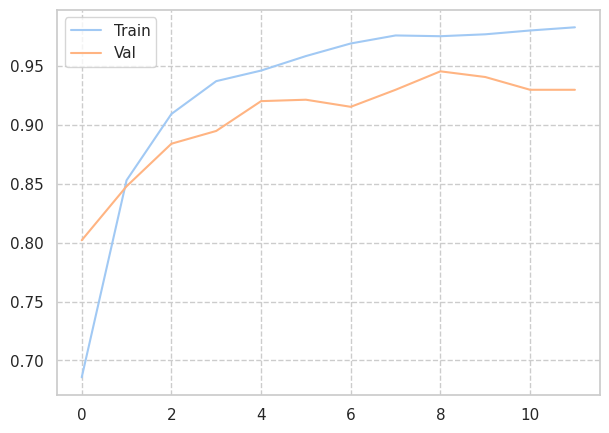

In [26]:
plt.figure(figsize= (7,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train", "Val"])

## 5.7 Evaluating Model on Testing Data

The trained CNN model is evaluated on the testing dataset to measure its performance on unseen data.

In [27]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss: ", test_loss)
print("Test Accuracy: ", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 661ms/step - accuracy: 0.9354 - loss: 0.1452
Test Loss:  0.11007025837898254
Test Accuracy:  0.9584980010986328


## 5.8 Model Predictions
The trained CNN model is evaluated on the testing dataset to measure its performance on unseen data.

#### Probability ranges: 0 - 1

The Middle point is (Threshold) 0.5

Since this is a binary classification problem, the model outputs probability values between 0 and 1. 
These probabilities are converted into class labels using a threshold.

- Output < 0.5 → Class 0 (fractured)
- Output ≥ 0.5 → Class 1 (not fractured)

In [28]:
test_generator.reset()

pred_probs = model.predict(test_generator)
predictions = (pred_probs > 0.5).astype(int).ravel()
predictions.shape

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step


(506,)

In [29]:
 true_labels = test_generator.classes

## 5.9 Confusion  Matrix

Confusion matrix - Evaluate the classification performance of the model by comparing actual and predicted labels.

- FP represents missed fractures (critical error)
- FN represents false alarms (less critical)
.

In [30]:
cm = confusion_matrix(true_labels, predictions)
print(cm)

[[227  11]
 [ 10 258]]


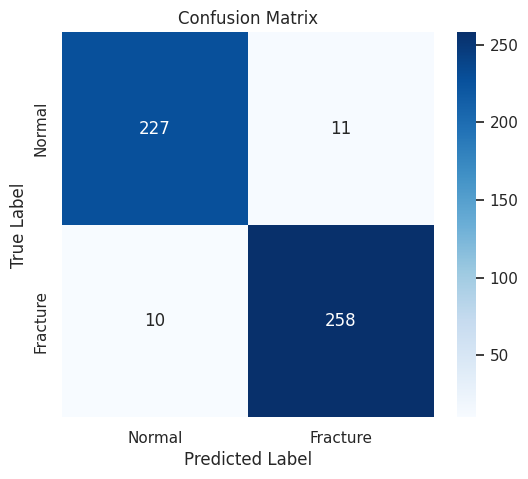

In [31]:
plt.figure(figsize= (6,5))

sns.heatmap(cm, annot= True, fmt = "d", cmap = "Blues",
           xticklabels = ["Normal", "Fracture"],
           yticklabels = ["Normal", "Fracture"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## 5.10 Classification Report

- ***Precision***: Measures how many predicted positives are correct
- ***Recall***: Measures how many actual positives are correctly identified
- ***F1-score***: Harmonic mean of precision and recall

In [32]:
print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       238
           1       0.96      0.96      0.96       268

    accuracy                           0.96       506
   macro avg       0.96      0.96      0.96       506
weighted avg       0.96      0.96      0.96       506



## 5.11 Saving CNN Model

In [33]:
model.save("cnn_model.h5")

# 6. Transfer Learning Approach

Transfer Learning is used to improve model performance by leveraging pre-trained models that were originally trained on large datasets like ImageNet.

Instead of training a model from scratch, pretrained models such as MobileNetV2, ResNet152V2, and VGG19 are used as feature extractors.

These models already understand general image features like edges, shapes, and textures, which can be adapted for fracture detection in X-ray images.

| Layer Type    | What it learns         |
| ------------- | ---------------------- |
| Early layers  | edges, lines (generic) |
| Middle layers | shapes                 |
| Last layers   | task-specific patterns |


## 6.1 Model Dictionary

1. **MobileNetV2** is a lightweight and efficient deep learning model designed for fast performance with fewer parameters.

> It uses depthwise separable convolutions, which reduce computation while maintaining accuracy. 

2. **ResNet152V2** is a very deep neural network with 152 layers that uses residual connections to avoid vanishing gradient problems.

> Residual connections allow the model to learn complex patterns effectively, even in very deep architectures.

3. ***VGG19*** is a deep convolutional neural network with 19 layers, known for its simple and uniform architecture.

> It uses small convolution filters (3x3) and focuses on learning hierarchical image features. Although powerful, it has a large number of parameters, making it slower and more computationally expensive.



In [34]:
models_dict = {
    "MobileNetV2": MobileNetV2,
    "ResNet152V2" : ResNet152V2,
    "VGG19" : VGG19    
}

## 6.2 Base Model and Custom Layers

In transfer learning, a pre-trained model is used as the base model, which has already learned general image features from large datasets like ImageNet.

On top of this base model, custom layers are added to adapt it to the specific task of fracture classification. 
These layers include Flatten, Dense, and Dropout layers, followed by a final output layer with sigmoid activation for binary classification.


In [35]:
def build_transfer_model(base_model_fn, input_shape = (224, 224, 3)):

    # 1. Loading Pretrained Model
    base_model = base_model_fn(
        weights = "imagenet",
        include_top = False,
        input_shape = input_shape
    )

    # 2. Only last 20 layers should be trainable"
    for layer in base_model.layers:
        layer.trainable = False

    # 3. Adding Custom Layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x) 
    x = Dense(128, activation = "relu")(x)
    x = Dense(132, activation = "relu")(x)

    # binary Classification
    output = Dense(1, activation = "sigmoid")(x)

    # 4. Creating Final Model
    model = Model(inputs = base_model.input, outputs = output)

    return model

## 6.3 Esembling Models

In [36]:
models = {}

for name, model_fn in models_dict.items():
    print(f"\nBuilding {name}....")
    models[name] = build_transfer_model(model_fn)


Building MobileNetV2....
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Building ResNet152V2....
234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Building VGG19....
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 6.3 Compiliation

In [37]:
for name, model in models.items():
    model.compile(
        optimizer = "adam",
        loss = "binary_crossentropy",
        metrics = ["accuracy"]
    )

## 6.4 Model Traning

- ***ModelCheckpoint*** is used with `save_best_only=True` to automatically save the model 
with the best validation accuracy during training.

- ***Early Stopping*** stops when model starts overfitting

In [38]:
history_dict = {}

for name, model in models.items():
    print(f"\nTraining {name}.....\n")

    # Checkpoint to saves BEST version, not last epoch
    checkpoint = ModelCheckpoint(
        f"{name}_best.keras",
        monitor = "val_accuracy",
        save_best_only = True
    )

    # Model fitting
    history = model.fit(
        train_generator,
        validation_data = val_generator,
        epochs = 15,
        callbacks = [checkpoint]
    )

    history_dict[name] = history


Training MobileNetV2.....

Epoch 1/15


2026-03-23 15:32:21.868323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 15:32:22.005470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


271/289 ━━━━━━━━━━━━━━━━━━━━ 7s 406ms/step - accuracy: 0.8196 - loss: 0.3844

2026-03-23 15:34:21.923865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 15:34:22.060805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8242 - loss: 0.3761

2026-03-23 15:34:48.230165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 15:34:48.374996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


289/289 ━━━━━━━━━━━━━━━━━━━━ 163s 508ms/step - accuracy: 0.8245 - loss: 0.3756 - val_accuracy: 0.9107 - val_loss: 0.2236
Epoch 2/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 118s 408ms/step - accuracy: 0.9629 - loss: 0.1015 - val_accuracy: 0.9626 - val_loss: 0.1249
Epoch 3/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 115s 398ms/step - accuracy: 0.9841 - loss: 0.0451 - val_accuracy: 0.9626 - val_loss: 0.1099
Epoch 4/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 118s 408ms/step - accuracy: 0.9858 - loss: 0.0369 - val_accuracy: 0.9626 - val_loss: 0.0901
Epoch 5/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 120s 416ms/step - accuracy: 0.9899 - loss: 0.0314 - val_accuracy: 0.9747 - val_loss: 0.0685
Epoch 6/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 117s 406ms/step - accuracy: 0.9913 - loss: 0.0241 - val_accuracy: 0.9759 - val_loss: 0.0733
Epoch 7/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 115s 398ms/step - accuracy: 0.9936 - loss: 0.0177 - val_accuracy: 0.9795 - val_loss: 0.0594
Epoch 8/15
289/289 ━━━━━━━━━━━━━━━━━━━━ 122s 422ms/step - accuracy: 0.9941 - loss: 0.01

## 6.5 Evaluating on Test Data

In [39]:
test_results = {}

for name, model in models.items():
    print(f"\nEvaluating {name}....\n")

    loss, acc = model.evaluate(test_generator)

    test_results[name] = {
        "loss" : loss,
        "accuracy" : acc
    }


    print(f"{name} -> Loss: {loss:.4f}, Accuracy: {acc:.4f}")


Evaluating MobileNetV2....

15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9994 - loss: 0.0068

2026-03-23 17:15:01.312245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 17:15:01.449264: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 934ms/step - accuracy: 0.9990 - loss: 0.0077
MobileNetV2 -> Loss: 0.0143, Accuracy: 0.9960

Evaluating ResNet152V2....

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 740ms/step - accuracy: 0.9762 - loss: 0.1007
ResNet152V2 -> Loss: 0.0402, Accuracy: 0.9901

Evaluating VGG19....

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8733 - loss: 0.2550 
VGG19 -> Loss: 0.2069, Accuracy: 0.9091


## 6.6 Predictions

In [40]:
evaluation_dict = {}

for name, model in models.items():
    print(f"\nProcessing {name}......\n")

    # Reset Generator
    test_generator.reset()

    # Predictions (Probabilities)
    y_pred_prob = model.predict(test_generator)

    # converted predicted probabilities into binary class labels by applying a threshold of 0.5, where values above 0.5 are classified as 1 and below as 0.
    y_pred = (y_pred_prob > 0.5).astype(int).ravel()

    # True LAbels
    y_true = test_generator.classes 

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Classification Report
    report = classification_report(y_true, y_pred, output_dict = True)

    # F1 Score
    f1 = f1_score(y_true, y_pred)

    # Storing each model’s evaluation results inside a dictionary for easy access and comparison
    evaluation_dict[name] = {
        "confusion_matrix": cm,
        "classification_report" : report,
        "f1_score": f1
    }

    print(f"{name} F1 Score: {f1:.4f}")
    
    


Processing MobileNetV2......

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 502ms/step
MobileNetV2 F1 Score: 0.9963

Processing ResNet152V2......

16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 861ms/step
ResNet152V2 F1 Score: 0.9907

Processing VGG19......

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 336ms/step
VGG19 F1 Score: 0.9151


## 6.7 Confusion Matrix


MobileNetV2 Confusion Matrix:



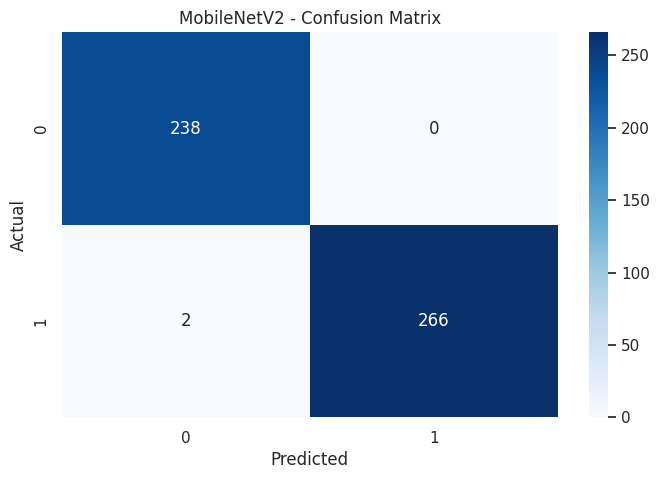


ResNet152V2 Confusion Matrix:



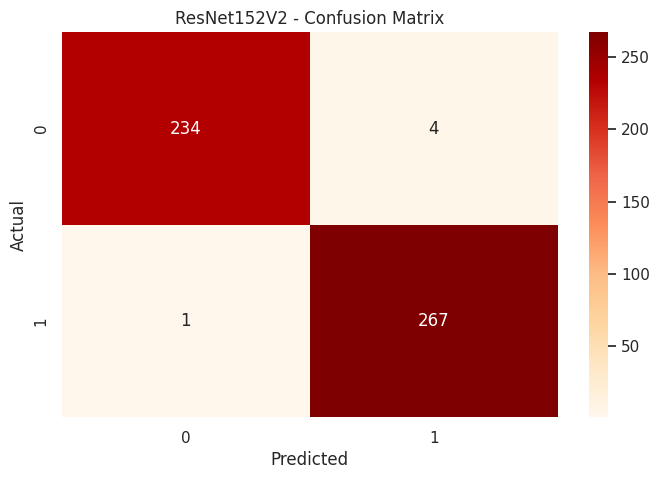


VGG19 Confusion Matrix:



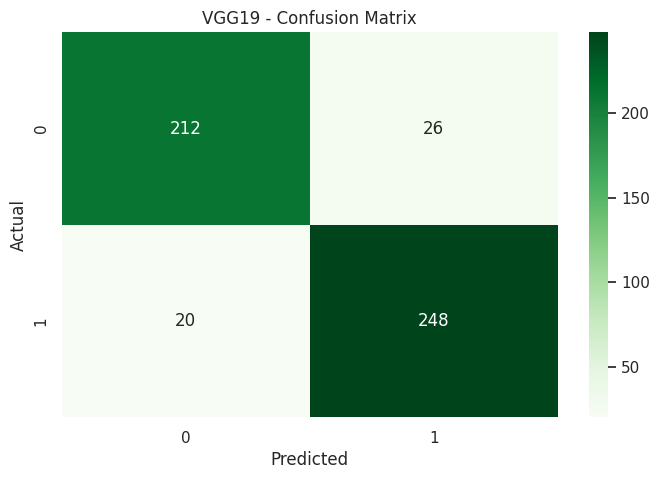

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correct color list
colors = ["Blues", "OrRd", "Greens", "Red"]

i = 0

for name in evaluation_dict:
    
    print(f"\n{name} Confusion Matrix:\n")

    cm = evaluation_dict[name]["confusion_matrix"]

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap=colors[i])
    
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    i += 1

## 6.8 Classification Report

In [42]:
for name in evaluation_dict:
    
    test_generator.reset()   # VERY IMPORTANT
    
    print(f"\n{name} Classification Report:\n")
    
    y_pred = (models[name].predict(test_generator) > 0.5).astype(int)
    
    print(classification_report(
        test_generator.classes,
        y_pred
    ))


MobileNetV2 Classification Report:

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 249ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       238
           1       1.00      0.99      1.00       268

    accuracy                           1.00       506
   macro avg       1.00      1.00      1.00       506
weighted avg       1.00      1.00      1.00       506


ResNet152V2 Classification Report:

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 280ms/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.99      1.00      0.99       268

    accuracy                           0.99       506
   macro avg       0.99      0.99      0.99       506
weighted avg       0.99      0.99      0.99       506


VGG19 Classification Report:

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 307ms/step
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       238
         

# 7. Final Results

The performance of multiple models was evaluated using accuracy and confusion matrix analysis.

While accuracy provides an overall measure of correctness, special attention was given to `false positives`, as they represent missed fractures in this medical application.

## 7.1 Model Comparison (Accuracy & False Positives)

The models were compared based on test accuracy and the number of false positives (FP).

- ***MobileNetV2*** achieved the highest accuracy (~99.6%) with zero false positives
- ***ResNet152V2*** achieved high accuracy (~99.0%) but had a few false positives
- ***VGG19*** showed comparatively lower accuracy (~91%) with higher misclassifications

In this project, false positives are critical because they represent `missed fracture cases`, which can lead to incorrect diagnosis.

Thus, minimizing false positives was prioritized over marginal accuracy differences.


## 7.2 Best Model

> MobileNetV2 was selected as the best-performing model.

It achieved the highest accuracy and, more importantly, zero false positives, meaning no fracture cases were missed.

This makes MobileNetV2 the most reliable model for this problem, especially in a medical context where missing a fracture can have serious consequences.

# 8. Conclusion

In this project, deep learning techniques were applied to classify X-ray images into fractured and non-fractured categories.

A baseline CNN model was built and later improved using transfer learning with pretrained models such as MobileNetV2, ResNet152V2, and VGG19.

Among all models, MobileNetV2 achieved the best performance with the highest accuracy and zero false positives, making it the most reliable model for fracture detection.

This project demonstrates the effectiveness of transfer learning in medical image classification and highlights the importance of evaluating models beyond accuracy, especially in critical applications.
